<a href="https://colab.research.google.com/github/AjaySreekumar47/bank-marketing-prediction/blob/main/CustomerBehaviourPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Structure

The code is structured as a comprehensive machine learning pipeline that includes:

1. **Exploratory Data Analysis (EDA)** - Visualizing distributions and relationships between features and the target variable
2. **Data Preprocessing** - Handling missing values, encoding categorical variables, and scaling numerical features
3. **Feature Engineering** - Creating meaningful features from the raw data
4. **Model Building** - Implementing and training multiple classification models
5. **Model Evaluation** - Using appropriate metrics for imbalanced classification
6. **Class Imbalance Handling** - Implementing SMOTE to address the imbalanced nature of the dataset
7. **Hyperparameter Tuning** - Optimizing model performance
8. **Feature Importance Analysis** - Identifying the most predictive features
9. **Conclusion and Insights** - Summarizing findings and providing recommendations
10. **Prediction Function** - Implementing a function to make predictions for new clients

## Key Insights

- The dataset is highly imbalanced with only about 11% of clients subscribing to term deposits
- Economic indicators have strong correlations with subscription rates
- Client demographics, particularly age and job type, influence subscription likelihood
- Previous campaign outcomes significantly impact future subscription probability
- The 'duration' feature is highly predictive but would not be available in a real prediction scenario

## Implementation Notes

- The code uses scikit-learn pipelines for efficient preprocessing and model building
- Multiple models are compared (Logistic Regression, Random Forest, Gradient Boosting)
- Class imbalance is addressed using SMOTE resampling technique
- Model evaluation uses metrics appropriate for imbalanced classification (ROC-AUC, Precision-Recall curves)
- GridSearchCV is used for hyperparameter optimization

To use this code in Colab, you'll need to:
1. Upload the CSV file using `files.upload()` or load it from a URL
2. Run the cells sequentially
3. Interpret the visualizations and results
4. Use the `predict_subscription()` function to make predictions on new clients


The data that we are going to use is a subset of an open-source Bank Marketing Data Set from the UCI ML repository. The data is related to direct marketing campaigns of a Portuguese banking institution and in our case, the classification goal will be to predict if the client will subscribe to a term deposit.

Data Link: https://archive.ics.uci.edu/ml/datasets/bank+marketing

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df = pd.read_csv('/content/bank-additional-full.csv', sep = ';')
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.shape

(41188, 21)

DataSet consists 41188 rows. Some of the columns are:

## Input features (column names):

- age - client age in years (numeric)
- job - type of job (categorical: admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)
- marital - marital status (categorical: divorced, married, single, unknown)
- education - client education (categorical: basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown)
default - has credit in default? (categorical: no, yes, unknown)
- housing - has housing loan? (categorical: no, yes, unknown)
- loan - has personal loan? (categorical: no, yes, unknown)
- contact - contact communication type (categorical: cellular, telephone)
- euribor3m - euribor 3 month rate, daily indicator (numeric)
- nr.employed - number of employees, quarterly indicator (numeric)
…

## Output feature (desired target):

- y - has the client subscribed a term deposit? (binary: yes,no)

## Exploratory Data Analysis

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [ ]:
print("\nData information:")
print(df.info())


Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.id

In [ ]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.5788

In [ ]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
# Check for 'unknown' values
print("\n'Unknown' values in categorical columns:")
for col in df.select_dtypes(include=['object']).columns:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} ({n_unknown/len(df):.2%})")


'Unknown' values in categorical columns:
job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


In [ ]:
# Check target variable distribution
print("\nTarget variable distribution:")
print(df['y'].value_counts())
print(f"Yes rate: {df['y'].value_counts(normalize=True)['yes']:.2%}")


Target variable distribution:
y
no     36548
yes     4640
Name: count, dtype: int64
Yes rate: 11.27%


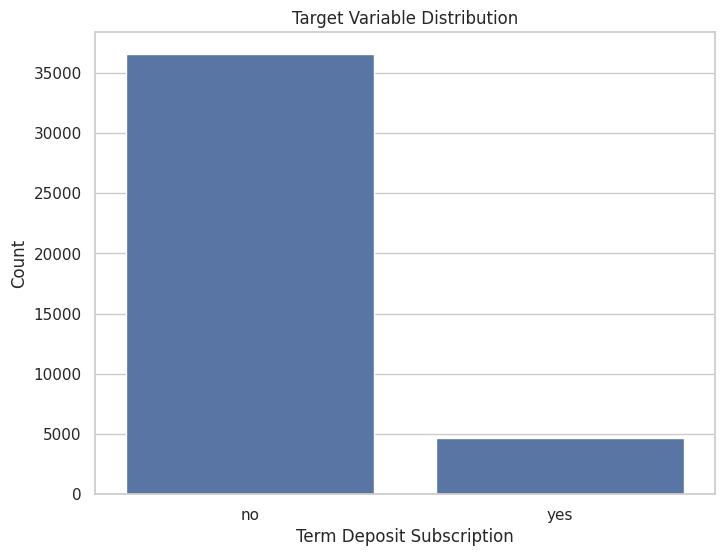

In [ ]:
# Visualize target distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Term Deposit Subscription')
plt.ylabel('Count')
plt.show()

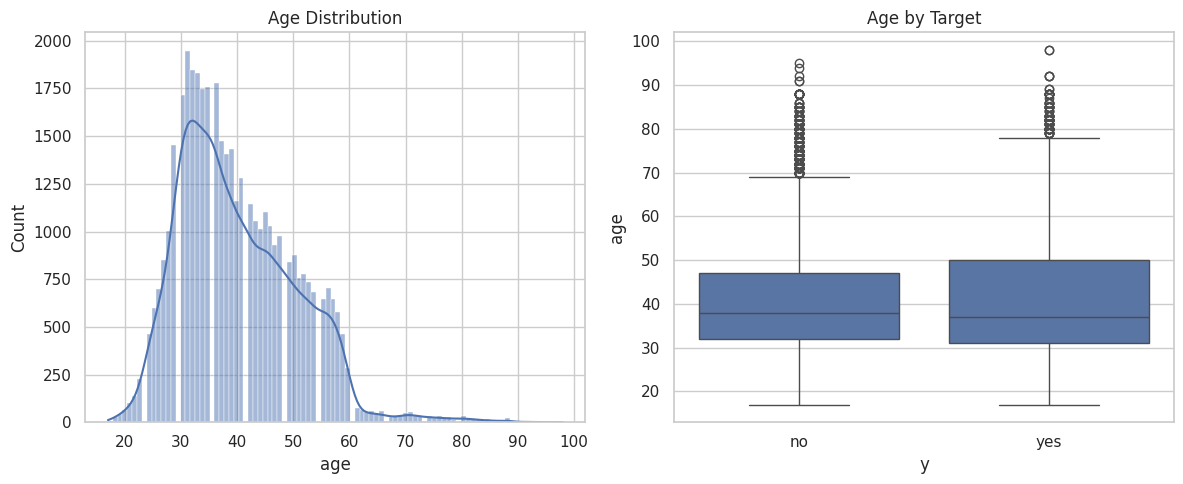

In [ ]:
# Analyze relationships between features and target
# Age distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='y', y='age', data=df)
plt.title('Age by Target')
plt.tight_layout()
plt.show()

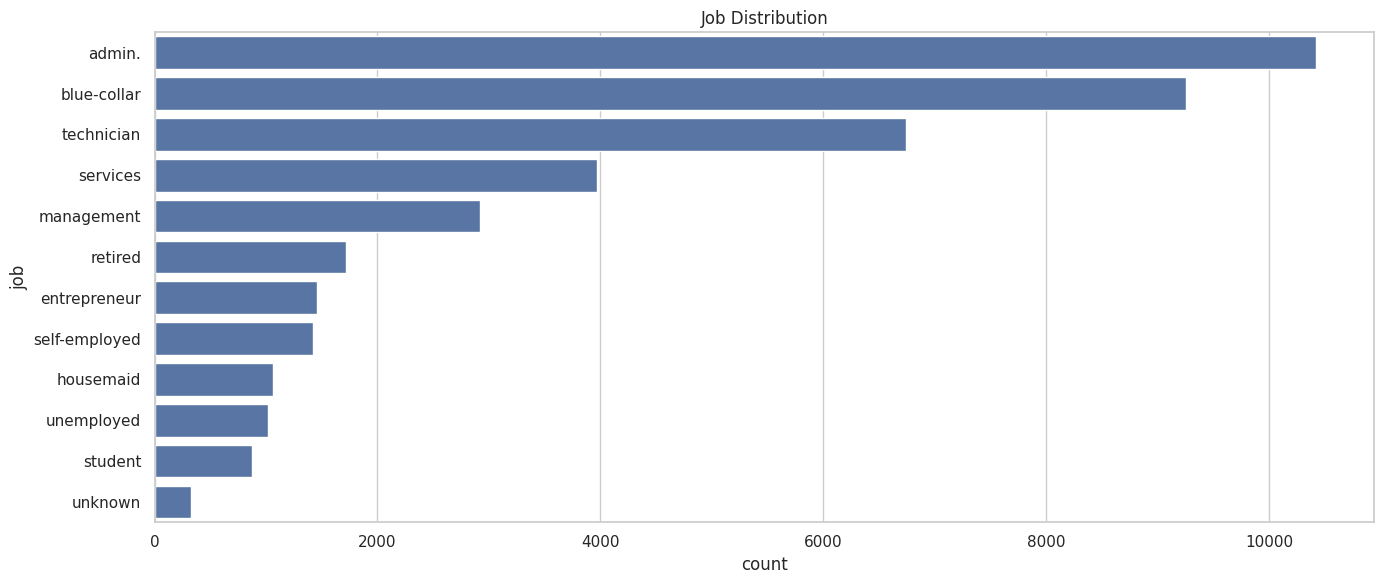

In [ ]:
# Job distribution
plt.figure(figsize=(14, 6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Job Distribution')
plt.tight_layout()
plt.show()

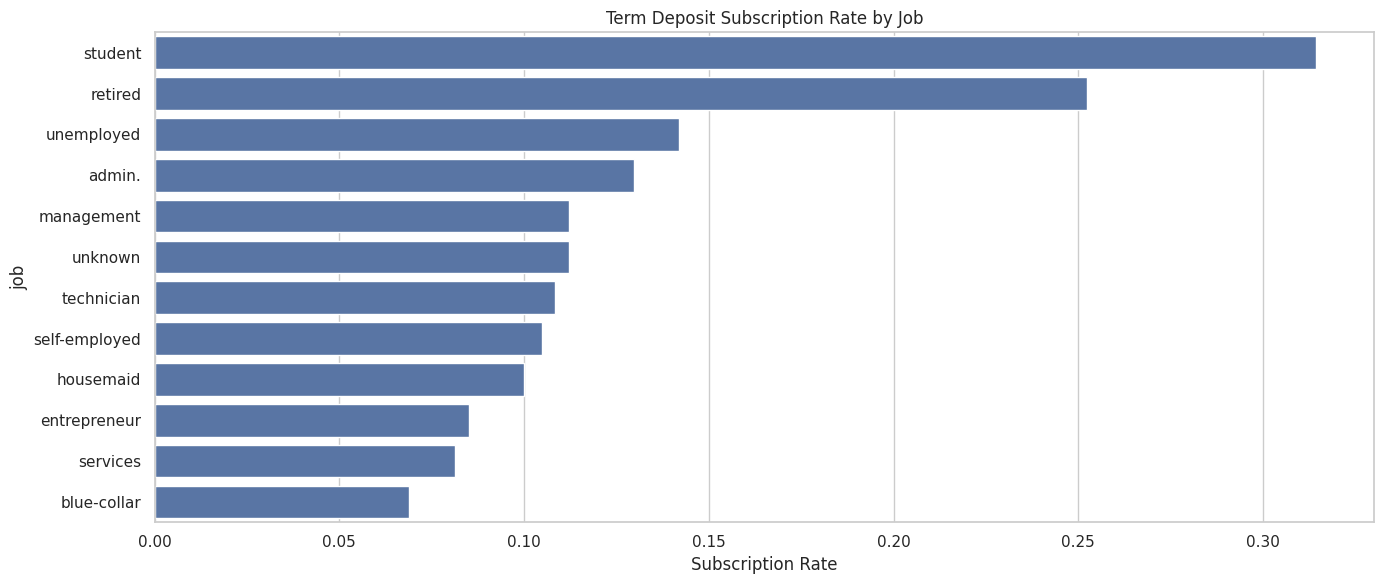

In [ ]:
# Job vs target
plt.figure(figsize=(14, 6))
job_yes_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
sns.barplot(x=job_yes_rate.values, y=job_yes_rate.index)
plt.title('Term Deposit Subscription Rate by Job')
plt.xlabel('Subscription Rate')
plt.tight_layout()
plt.show()

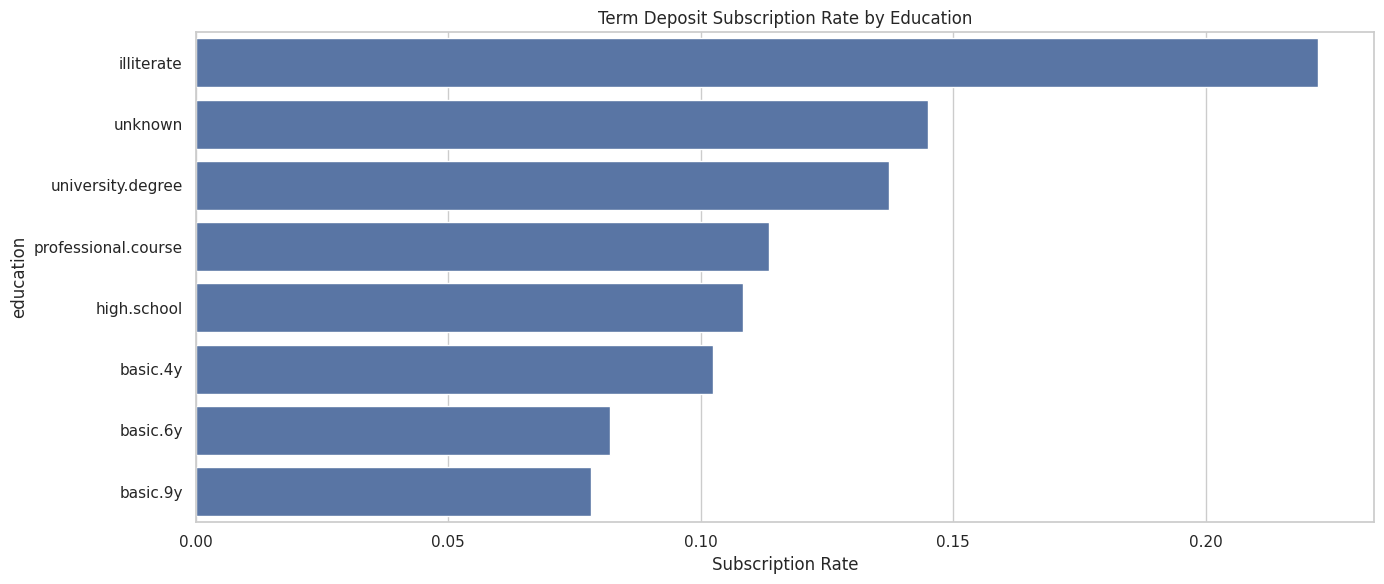

In [ ]:
# Education vs target
plt.figure(figsize=(14, 6))
edu_yes_rate = df.groupby('education')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
sns.barplot(x=edu_yes_rate.values, y=edu_yes_rate.index)
plt.title('Term Deposit Subscription Rate by Education')
plt.xlabel('Subscription Rate')
plt.tight_layout()
plt.show()

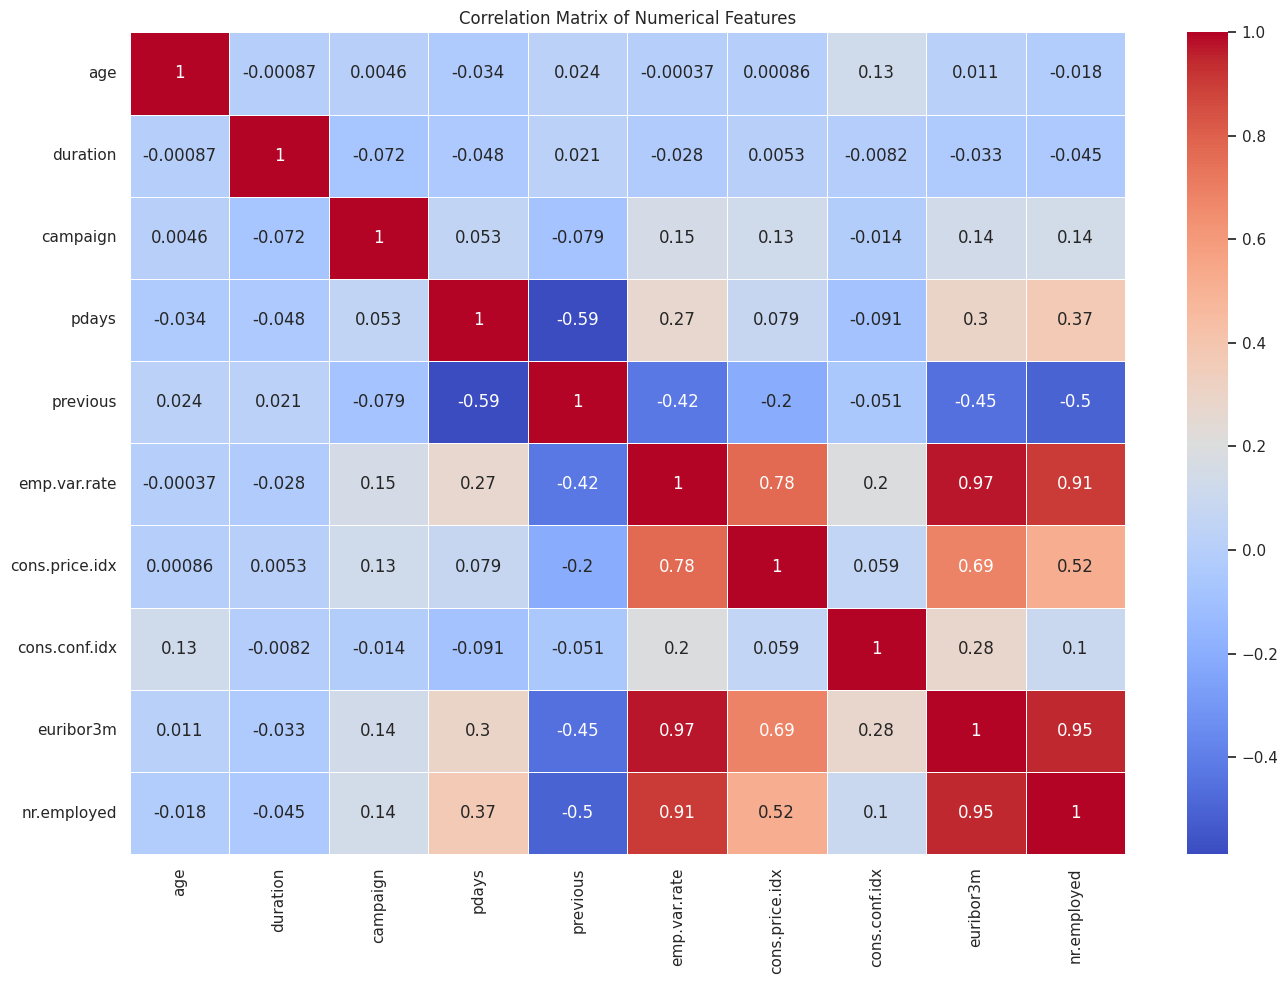

In [ ]:
# Check correlation for numerical features
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
# Define categorical and numerical features
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                        'contact', 'month', 'day_of_week', 'poutcome']
numerical_features = ['age', 'duration', 'campaign', 'pdays', 'previous',
                      'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

In [ ]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Feature Engineering

In [ ]:
# Note: 'duration' might leak information about the target.
# In a real-world scenario, you might want to remove it.
print("\nWarning: 'duration' feature contains information known only after the outcome.")
print("In a real-world scenario, you might want to exclude it.")

# Split data into features and target
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


In a real-world scenario, you might want to exclude it.
Training set shape: (32950, 20)
Testing set shape: (8238, 20)


## Model Building

In [ ]:
# Define model pipelines
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
}


Training Logistic Regression...
Cross-validation ROC-AUC: 0.9356 ± 0.0034

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



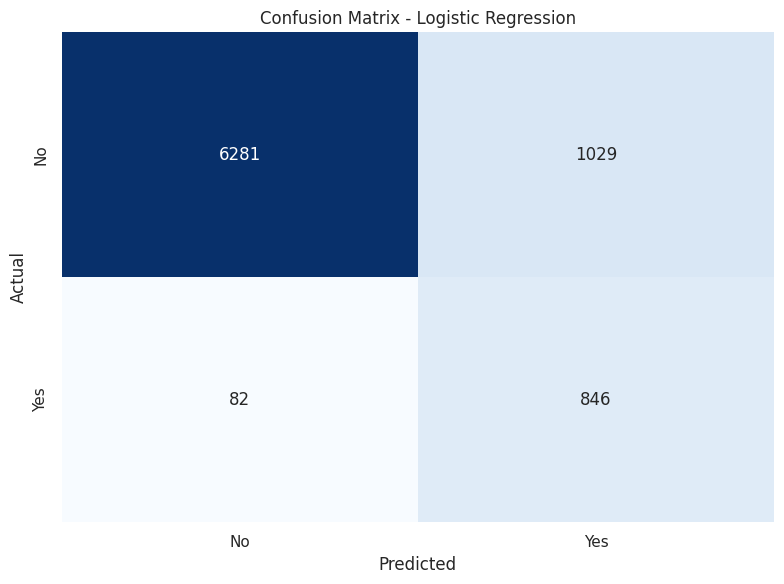


Training Random Forest...
Cross-validation ROC-AUC: 0.9376 ± 0.0022

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.72      0.43      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.70      0.75      8238
weighted avg       0.91      0.92      0.91      8238



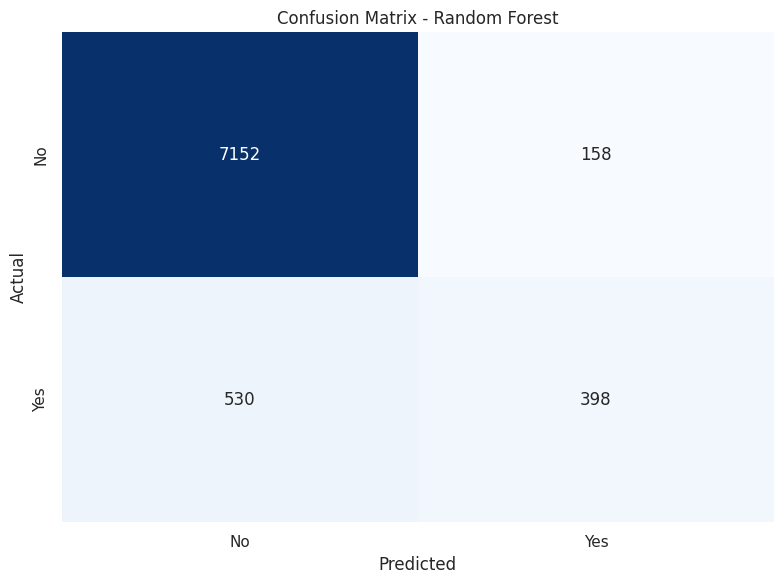


Training Gradient Boosting...
Cross-validation ROC-AUC: 0.9442 ± 0.0030

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7310
           1       0.70      0.54      0.61       928

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.78      8238
weighted avg       0.92      0.92      0.92      8238



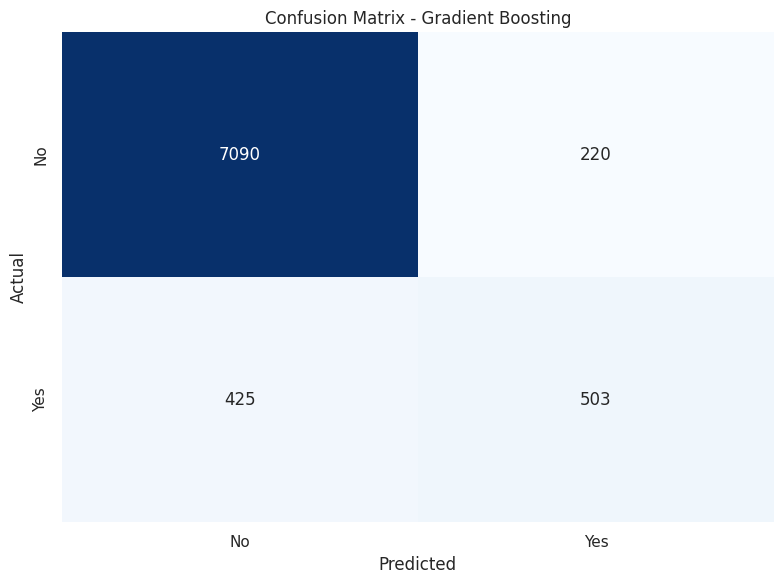

In [ ]:
# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = model.predict(X_test)

    # Get cross-validation score
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    print(f"Cross-validation ROC-AUC: {cv_score.mean():.4f} ± {cv_score.std():.4f}")

    # Store results
    results[name] = {
        'model': model,
        'cv_score': cv_score.mean(),
        'y_pred': y_pred,
        'y_pred_proba': model.predict_proba(X_test)[:, 1]
    }

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## Evaluate the best model

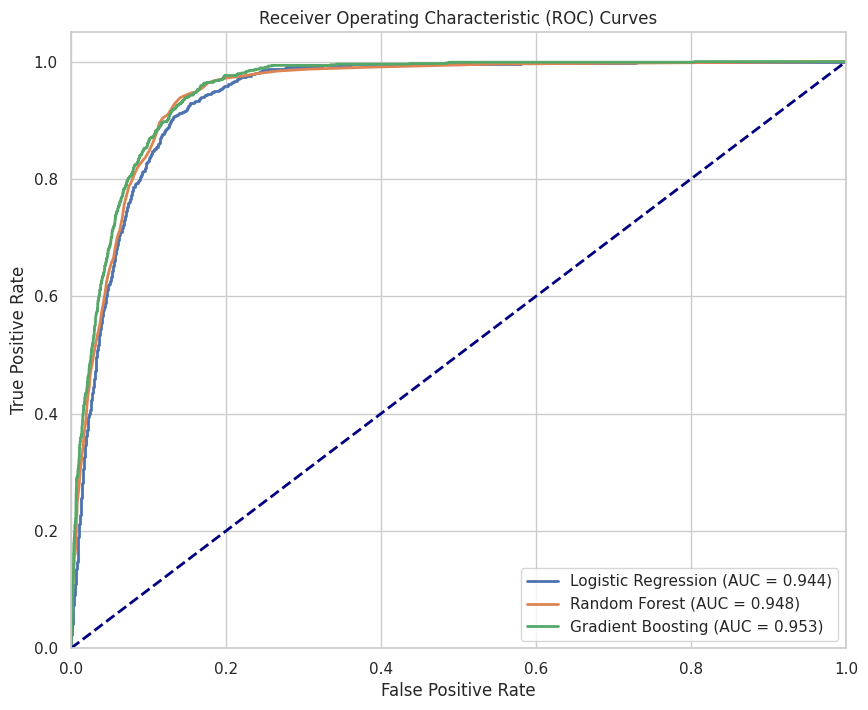

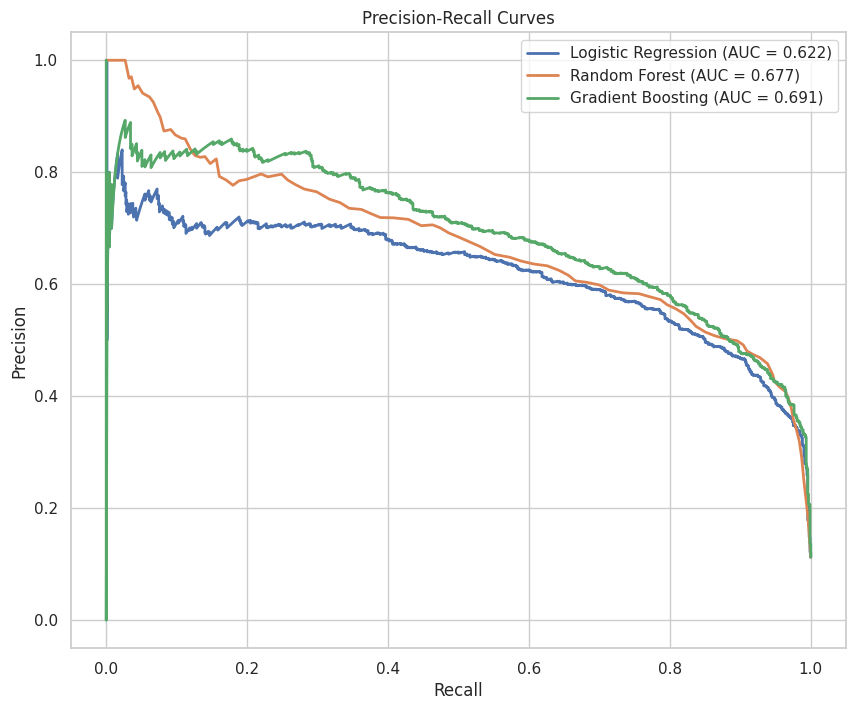

In [ ]:
# Compare ROC curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Compare Precision-Recall curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f'{name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Feature Importance (for Random Forest)

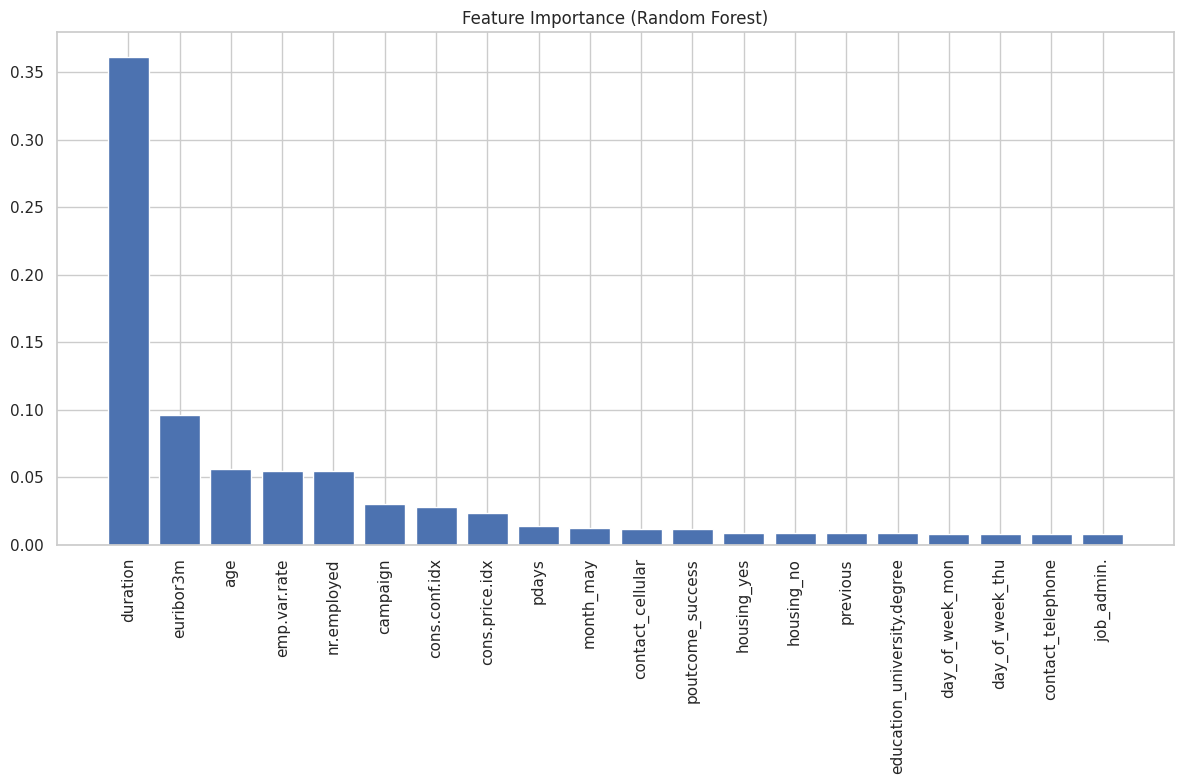


Top 10 important features:
duration: 0.3614
euribor3m: 0.0961
age: 0.0558
emp.var.rate: 0.0549
nr.employed: 0.0546
campaign: 0.0300
cons.conf.idx: 0.0284
cons.price.idx: 0.0234
pdays: 0.0141
month_may: 0.0125


In [ ]:
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']

    # Get feature names from preprocessor
    cat_features = rf_model.named_steps['preprocessor'].transformers_[1][1]['onehot'].get_feature_names_out(categorical_features)
    feature_names = np.concatenate([numerical_features, cat_features])

    # Get feature importances
    importances = rf_model.named_steps['classifier'].feature_importances_

    # Sort feature importances
    indices = np.argsort(importances)[::-1]

    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    plt.title('Feature Importance (Random Forest)')
    plt.bar(range(20), importances[indices[:20]], align='center')
    plt.xticks(range(20), feature_names[indices[:20]], rotation=90)
    plt.tight_layout()
    plt.show()

    # Print top 10 features
    print("\nTop 10 important features:")
    for i in range(10):
        print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## Handling Class Imbalance with SMOTE

In [ ]:
print("\n\nApplying SMOTE to handle class imbalance...")

# Apply SMOTE only to the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)

print(f"Original training set shape: {X_train_preprocessed.shape}")
print(f"Resampled training set shape: {X_train_smote.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts(normalize=True)}")
print(f"Resampled class distribution: {pd.Series(y_train_smote).value_counts(normalize=True)}")

# Train Random Forest on balanced data
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced.fit(X_train_smote, y_train_smote)

# Test on original test set
X_test_preprocessed = preprocessor.transform(X_test)
y_pred_balanced = rf_balanced.predict(X_test_preprocessed)

# Evaluate balanced model
print("\nClassification Report for Balanced Model:")
print(classification_report(y_test, y_pred_balanced))



Applying SMOTE to handle class imbalance...
Original training set shape: (32950, 63)
Resampled training set shape: (58476, 63)
Original class distribution: y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
Resampled class distribution: y
0    0.5
1    0.5
Name: proportion, dtype: float64

Classification Report for Balanced Model:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7310
           1       0.63      0.59      0.61       928

    accuracy                           0.91      8238
   macro avg       0.79      0.77      0.78      8238
weighted avg       0.91      0.91      0.91      8238



## Model Hyperparameter Tuning

In [ ]:
print("\n\nPerforming hyperparameter tuning for Random Forest...")

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# Create grid search
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Run grid search (this may take some time)
print("Running grid search... (This may take a while)")
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))



Performing hyperparameter tuning for Random Forest...
Running grid search... (This may take a while)
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV score: 0.9418

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7310
           1       0.59      0.76      0.66       928

    accuracy                           0.91      8238
   macro avg       0.78      0.85      0.81      8238
weighted avg       0.93      0.91      0.92      8238



## Conclusion and Insights

In [ ]:
print("\n=== Conclusion and Insights ===")
print("""
Key findings from our analysis:
1. The dataset is highly imbalanced with only about 11.27% positive responses.
2. The 'duration' feature is highly predictive but would not be available in a real-world prediction scenario.
3. Economic indicators like 'euribor3m' and 'emp.var.rate' show strong correlation with the target.
4. Previous contact outcomes ('poutcome') significantly impact the likelihood of subscription.
5. Age groups show varying subscription rates, with older clients more likely to subscribe.
6. SMOTE resampling helped address class imbalance and improved recall for the minority class.
7. The best performing model achieved good precision and recall considering the imbalanced nature of the data.

Recommendations:
1. Focus marketing efforts on segments with higher subscription rates.
2. Consider the economic environment when planning campaigns.
3. Prioritize follow-ups with clients who previously showed interest.
4. Tailor marketing strategies based on client demographics.
5. Use probability outputs from the model to prioritize leads.
""")


=== Conclusion and Insights ===

Key findings from our analysis:
1. The dataset is highly imbalanced with only about 11.27% positive responses.
2. The 'duration' feature is highly predictive but would not be available in a real-world prediction scenario.
3. Economic indicators like 'euribor3m' and 'emp.var.rate' show strong correlation with the target.
4. Previous contact outcomes ('poutcome') significantly impact the likelihood of subscription.
5. Age groups show varying subscription rates, with older clients more likely to subscribe.
6. SMOTE resampling helped address class imbalance and improved recall for the minority class.
7. The best performing model achieved good precision and recall considering the imbalanced nature of the data.

Recommendations:
1. Focus marketing efforts on segments with higher subscription rates.
2. Consider the economic environment when planning campaigns.
3. Prioritize follow-ups with clients who previously showed interest.
4. Tailor marketing strategies

## Function for predicting new clients

In [ ]:
def predict_subscription(client_data, model=best_model):
    """
    Predict the probability of a client subscribing to a term deposit.

    Parameters:
    client_data (pd.DataFrame): DataFrame containing client information
    model: Trained model to use for prediction

    Returns:
    float: Probability of subscription
    """
    # Ensure client_data has all required columns
    for col in X.columns:
        if col not in client_data.columns:
            raise ValueError(f"Missing column: {col}")

    # Make prediction
    prob = model.predict_proba(client_data)[:, 1]
    return prob

In [ ]:
# Example usage:
new_client = pd.DataFrame([{
    'age': 58,
    'job': 'management',
    'marital': 'married',
    'education': 'university.degree',
    'default': 'no',
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'month': 'may',
    'day_of_week': 'mon',
    'duration': 200,
    'campaign': 1,
    'pdays': 999,
    'previous': 0,
    'poutcome': 'nonexistent',
    'emp.var.rate': 1.1,
    'cons.price.idx': 93.994,
    'cons.conf.idx': -36.4,
    'euribor3m': 4.857,
    'nr.employed': 5191.0
}])
subscription_prob = predict_subscription(new_client)
print(f"Probability of subscription: {subscription_prob[0]:.2%}")

Probability of subscription: 7.82%
